# Test
Si addestri il regressore desiderato utilizzando gli iperparametri trovati nell'esercizio precedente. Il codice contenuto nella cella seguente userà tale regressore per predire la potenza prodotta nell'ora successiva a partire dai pattern del dataset di test. I valori predetti verranno memorizzati su un file di testo che dovrà essere caricato sul sito della competizione per misurarne l'RMSE.

In [247]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from pre_processing import extract_datetime_feature, augment_celsius, pre_process,augment_cycle_variable,get_dataset_features
from matplotlib import pyplot as plt

BEGIN FEATURE ENGINEERING...
datatime extracted!
END FEATURE ENGINEERING
BEGIN AUGMENTATION ...
temperature augmented!
cycles augmented!
BEGIN CLEANING ...
193 mid zeros rows removed
70 inconsistent rows removed
52 drop_table rows removed
Before hand cleaning


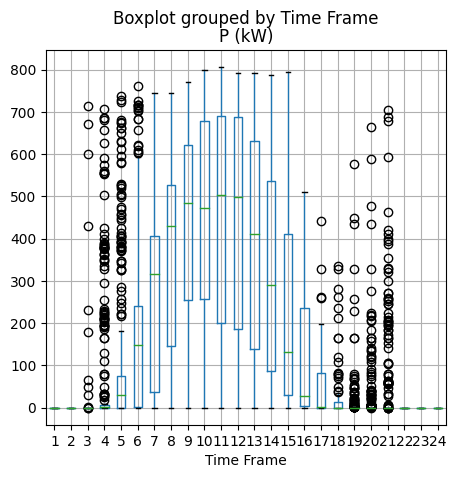

After hand cleaning


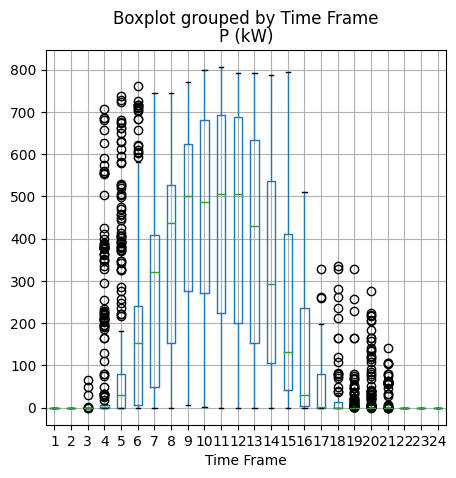

hand cleaned!
year fused!
END AUGMENTATION
prevent feature hour__sin to remove zeros outliers (change secure to remove)
prevent feature hour__sin to remove zeros outliers (change secure to remove)
188 outliers rows removed
prevent feature hour__cos to remove zeros outliers (change secure to remove)
prevent feature hour__cos to remove zeros outliers (change secure to remove)
188 outliers rows removed
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature Time Frame__sin to remove zeros outliers (change secure to remove)
prevent feature 

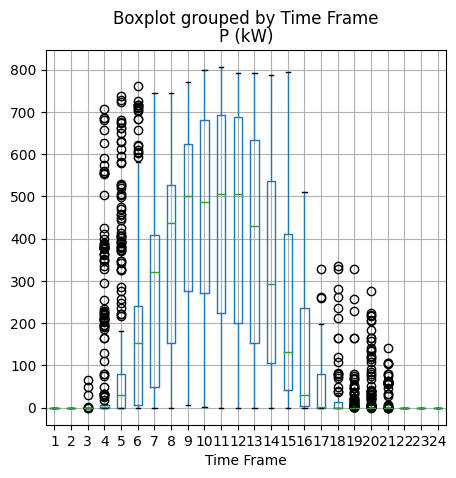

After outliers cleaning


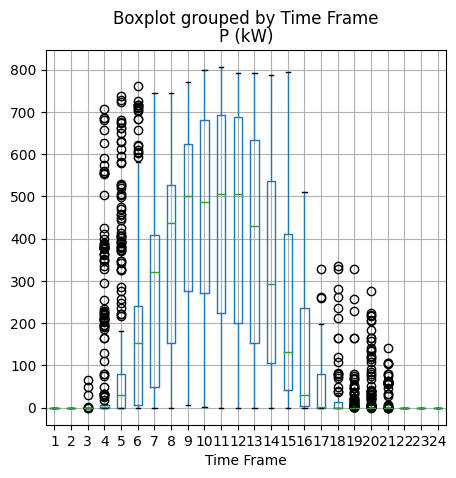

BEGIN EXTENSION ...
263 data_remove ROWS!


 22%|██▏       | 272/1212 [00:02<00:09, 100.95it/s]

789 rows extended to dataframe!


100%|█████████▉| 1211/1212 [00:11<00:00, 111.90it/s]

3636 rows extended to dataframe!
END EXTENSION
NORMAL - Before extensions


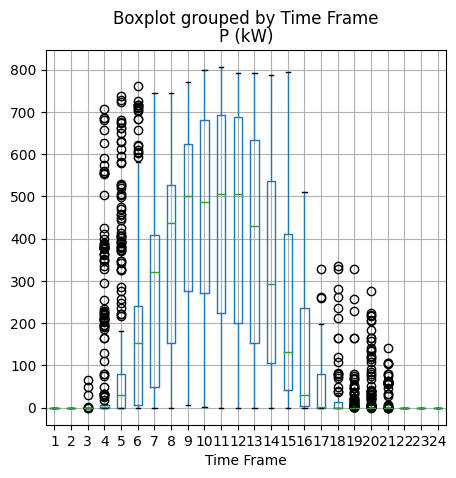

NORMAL - After extensions


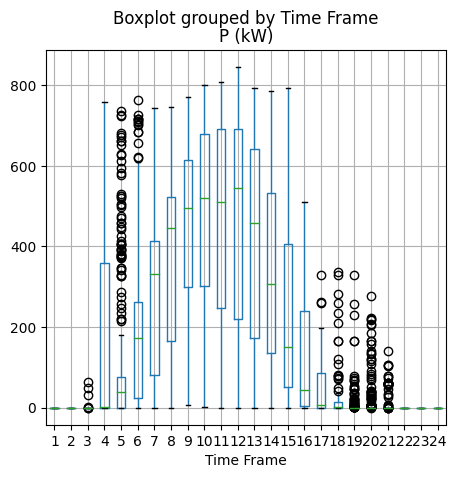

PURE - Before extensions


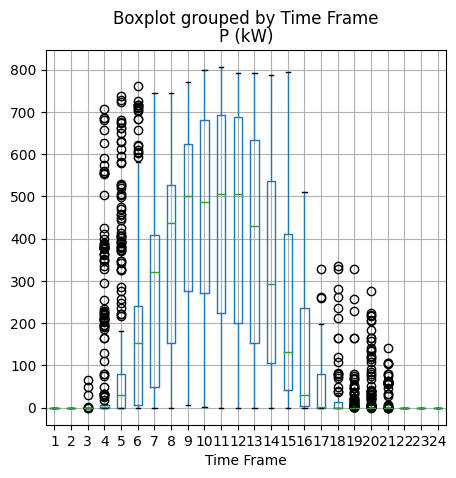

PURE - After extensions


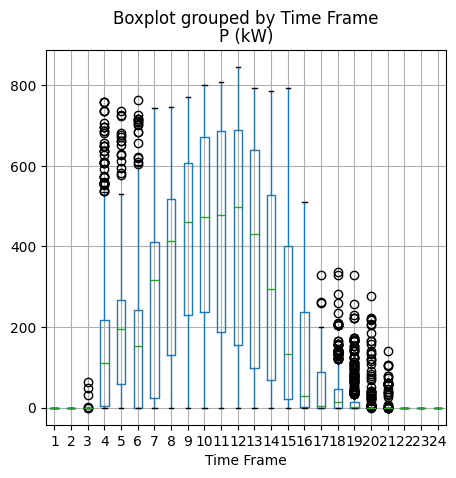

100%|██████████| 1212/1212 [00:12<00:00, 96.36it/s] 

END CLEANING
BEGIN NORMALIZATION ...
Rounded data by 1!
END NORMALIZATION ...
Column Unnamed: 0 does not exist in the DataFrame.
Column Tm (F) does not exist in the DataFrame.
Column notes does not exist in the DataFrame.
Column note does not exist in the DataFrame.
Column Unnamed: 0 does not exist in the DataFrame.
Column Tm (F) does not exist in the DataFrame.
Column notes does not exist in the DataFrame.
Column note does not exist in the DataFrame.
Column P (kW) does not exist in the DataFrame.
Column Unnamed: 0 does not exist in the DataFrame.
Column Tm (F) does not exist in the DataFrame.
Column notes does not exist in the DataFrame.
Column note does not exist in the DataFrame.


In [256]:
train_path = './DBs/SolarPark/train.txt'
test_path = './DBs/SolarPark/test.txt'
result_path = 'Es5Predictions.txt'

useless_column=["Date","year","month","day","hour","minute","day_of_week","day_of_year","day_part","is_year_start","is_month_start","is_quarter_start","is_month_end","is_weekend","Unnamed: 0","Tm (F)","notes","note"]
train_dataframe,train_pure_dataframe = pre_process(train_path,d=True,extension=True,rounding=1)
feature_x, feature_y = get_dataset_features(train_dataframe, "P (kW)", useless_column)
feature_pure_x, feature_pure_y = get_dataset_features(train_pure_dataframe, "P (kW)", useless_column=useless_column)

# Cast di tutti i valori a float32
feature_x = feature_x.astype(np.float32)
feature_y = feature_y.astype(np.float32)

# Cast di tutti i valori a float32
feature_pure_x = feature_pure_x.astype(np.float32)
feature__pure_y = feature_pure_y.astype(np.float32)

test_dataframe = pd.read_csv(test_path)
test_dataframe = extract_datetime_feature(df=test_dataframe, date_column='Date', remove=False, is_timestamp=True)
test_dataframe = augment_celsius(df=test_dataframe, replace=False, columns=["Ta (C)", "Tm (C)"])
test_dataframe = augment_cycle_variable(df=test_dataframe, replace=False, columns=["Time Frame", "month", "day",
                                                                         "hour", "minute", "day_of_year",
                                                                         "day_of_week"])
test_dataframe = augment_cycle_variable(df=test_dataframe, replace=False, columns=["hour"])
test_x, _ = get_dataset_features(test_dataframe, "P (kW)", useless_column=useless_column)
test_x = test_x.astype(np.float32)



In [265]:
predict_ahead = True

if predict_ahead:
    # Sfasa i dati: le prediction sono quelle dell'ora successiva
    data_x = feature_x[0:-1,:]
    data_y = feature_y[1:]
    data_pure_x = feature_pure_x[0:-1,:]
    data_pure_y = feature_pure_y[1:]
else:
    data_x = feature_x
    data_y = feature_y
    data_pure_x = feature_pure_x
    data_pure_y = feature_pure_y

In [266]:
train_dataframe

,Time Frame,Date,Ta (C),Tm (C),I3 (W/m2),I15 (W/m2),P (kW),year,month,day,...,day__sin,day__cos,hour__sin,hour__cos,minute__sin,minute__cos,day_of_year__sin,day_of_year__cos,day_of_week__sin,day_of_week__cos
0,16,2012-03-05 16:55:00,13.01,12.05,52.47,53.08,6.50,2012,3,5,...,0.724793,0.688967,-9.694003e-01,0.245485,0.324699,-0.945817,0.932173,0.362013,0.000000,1.00000
1,17,2012-03-05 17:55:00,11.81,8.50,10.41,10.95,0.01,2012,3,5,...,0.724793,0.688967,-8.371665e-01,0.546948,0.324699,-0.945817,0.932173,0.362013,0.000000,1.00000
2,18,2012-03-05 18:55:00,10.33,5.68,0.00,0.00,0.00,2012,3,5,...,0.724793,0.688967,-6.142127e-01,0.789141,0.324699,-0.945817,0.932173,0.362013,0.000000,1.00000
3,19,2012-03-05 19:55:00,9.66,4.67,0.00,0.00,0.00,2012,3,5,...,0.724793,0.688967,-3.246995e-01,0.945817,0.324699,-0.945817,0.932173,0.362013,0.000000,1.00000
4,20,2012-03-05 20:55:00,8.91,3.82,0.00,0.00,0.00,2012,3,5,...,0.724793,0.688967,-2.449294e-16,1.000000,0.324699,-0.945817,0.932173,0.362013,0.000000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8072,17,2013-01-13 17:53:00,14.70,18.20,159.67,150.87,68.86,2013,1,13,...,0.651372,-0.758758,-8.371665e-01,0.546948,0.614213,-0.789141,0.223174,0.974779,-0.781831,0.62349
8073,17,2013-01-13 17:53:00,14.70,18.20,159.67,144.26,68.86,2013,1,13,...,0.651372,-0.758758,-8.371665e-01,0.546948,0.614213,-0.789141,0.223174,0.974779,-0.781831,0.62349
8074,18,2013-01-13 18:53:00,13.75,15.19,88.73,100.58,13.78,2013,1,13,...,0.651372,-0.758758,-6.142127e-01,0.789141,0.614213,-0.789141,0.223174,0.974779,-0.781831,0.62349
8075,18,2013-01-13 18:53:00,13.75,15.19,24.12,100.58,13.78,2013,1,13,...,0.651372,-0.758758,-6.142127e-01,0.789141,0.614213,-0.789141,0.223174,0.974779,-0.781831,0.62349


In [267]:
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression

model_params = {
    'RandomForestRegressor': {
        'model': RandomForestRegressor(),
        'params' : {
            'n_estimators' : [100], # 300, 500, 700], #numero di alberi utilizzati (maggiore incrementa le performance e permette predizioni più stabili) #300,500,700,1000
            'max_depth' : [None], # The maximum depth of the tree. e.g. 3,5,7,10
            "max_features": ["sqrt"], # e.g. [“sqrt”, “log2”, None]
            "min_samples_leaf": [1], # istanze dei nodi foglia ---default 1
            "min_samples_split": [2], # istanze dei nodi interni ---default 2
            'criterion' : ['squared_error'] # ---default 'squared_error', then 'absolute_error', 'poisson'
        }
    },
    'LinearRegressor': {
        'model': LinearRegression(),
        'params' : {
            'fit_intercept': [True], # if False, data is expected to be centered
            'copy_X': [True], # If True, X will be copied; else, it may be overwritten.
            'n_jobs': [-1],
            'positive': [False] # When set to True, forces the coefficients to be positive
        }
    }
}


votingRegressorModel = VotingRegressor([
    ('rf', RandomForestRegressor(**model_params['RandomForestRegressor']['params'])),
    ('lr', LinearRegression(**model_params['LinearRegressor']['params']))
])




In [268]:
import pre_processing


regressor = pre_processing.getBestRegressor(model_params, data_x, data_y, test_size=[0.25], n_split=[3], useVotingRegressor=True)
regressor_pure = pre_processing.getBestRegressor(model_params, data_pure_x, data_pure_y, test_size=[0.25], n_split=[3], useVotingRegressor=True)
regressor.printVals()

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
Best score replaced: 
New:  0.9244090345863443
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END copy_X=True, fit_intercept=True, n_jobs=-1, positive=False; total time=   0.0s
[CV] END copy_X=True, fit_intercept=True, n_jobs=-1, positive=False; total time=   0.0s
[CV] END copy_X=True, fit_intercept=True, n_jobs=-1, positive=False; total time=   0.0s
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END lr__copy_X=True, lr__fit_intercept=True, lr__n_jobs=-1, lr__po

In [271]:
forest = RandomForestRegressor(n_estimators=50)
forest.fit(data_x,data_y)
prediction = forest.predict(test_x)


In [269]:
prediction = regressor._regressor.predict(test_x)
prediction_pure = regressor_pure._regressor.predict(test_x)

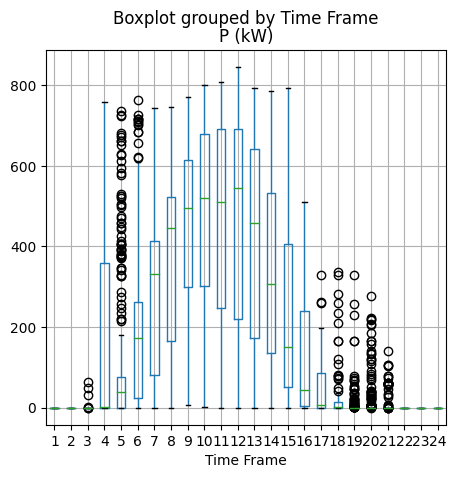

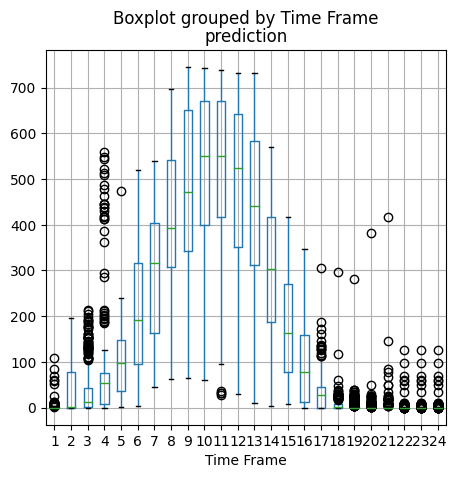

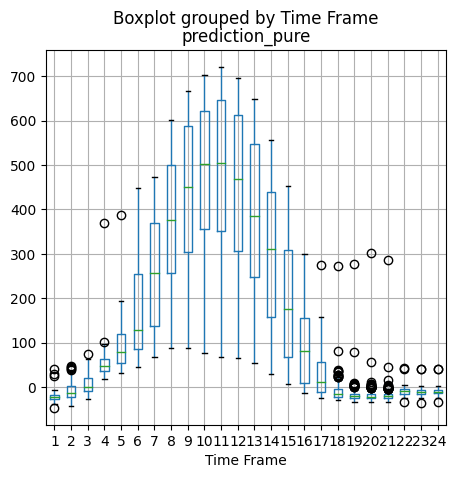

In [272]:
train_dataframe.boxplot(column='P (kW)', by='Time Frame', figsize=(5, 5))
plt.show()
test_dataframe['prediction'] = prediction
test_dataframe['prediction_pure'] = prediction_pure
test_dataframe.boxplot(column='prediction', by='Time Frame', figsize=(5, 5))
plt.show()
test_dataframe.boxplot(column='prediction_pure', by='Time Frame', figsize=(5, 5))
plt.show()